<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Points---sanity" data-toc-modified-id="Points---sanity-1">Points - sanity</a></span></li><li><span><a href="#Lines-&amp;-Project-Coordinate-System" data-toc-modified-id="Lines-&amp;-Project-Coordinate-System-2">Lines &amp; Project Coordinate System</a></span></li><li><span><a href="#Polygons---Geographic-coordinate-system" data-toc-modified-id="Polygons---Geographic-coordinate-system-3">Polygons - Geographic coordinate system</a></span></li><li><span><a href="#Very-large-data" data-toc-modified-id="Very-large-data-4">Very large data</a></span></li></ul></div>

In [7]:
## uncomment this if you are testing a non-installed version of the Python API and update the path
# ##
# import sys
# sys.path.insert(0, r"E:\\code\\geosaurus\\geosaurus\\src")
# import os

In [5]:
import arcgis
print(arcgis.__file__)
import pandas as pd
from arcgis.features import GeoAccessor
import geopandas as gpd
import matplotlib.pyplot as plt
import os

%matplotlib inline

e:\code\geosaurus\geosaurus\src\arcgis\__init__.py


In [50]:
data_path = r'\\qalab_server\pydata\v108\geosaurus\data_prep\spatial_ref_tests'
large_data_path = r'\\qalab_server\pydata\v108\geosaurus\Esri_Geoanalytics_datasets'

In [3]:
from arcgis.gis import GIS
gis = GIS()

## Points - sanity

In [6]:
%%time
file_path = os.path.join(data_path, 'points_gcs_nad83.shp')
geo_df = gpd.read_file(file_path)

Wall time: 129 ms


In [7]:
geo_df.shape

(317, 30)

In [8]:
geo_df.head(2)

,objectid,post_id,name,descriptio,cat1,cat2,cat3,addrln1,addrln2,city,...,source,ext_id,use_type,dis_status,latitude,longitude,date_updat,point_x,point_y,geometry
0,40221950,638.0,Hollywood Community Hospital,The agency provides hospital services for peop...,Health and Mental Health,Hospitals and Medical Centers,None,6245 De Longpre Ave.,None,Hollywood,...,211,None,publish,None,34.096313,-118.325079,2013-06-01,6.463252e+06,1.857590e+06,POINT (-118.32508 34.09631)
1,40222889,1268.0,Los Angeles Community Hospital,The facility provides hospital services for pe...,Health and Mental Health,Hospitals and Medical Centers,None,4081 E. Olympic Blvd.,None,Los Angeles,...,211,None,publish,None,34.019102,-118.186366,2013-06-01,6.505195e+06,1.829384e+06,POINT (-118.18637 34.01910)


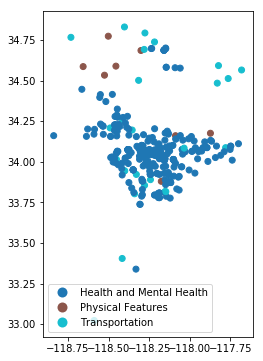

In [9]:
fig, ax = plt.subplots(figsize=(6,6))
geo_df.plot(column ='cat1', legend=True, ax=ax);

In [12]:
%%time
sedf = pd.DataFrame.spatial.from_geodataframe(geo_df)
sedf.shape

Wall time: 65.5 ms


In [11]:
sedf.head(2)

,SHAPE,addrln1,addrln2,cat1,cat2,cat3,city,date_updat,descriptio,dis_status,...,org_name,phones,point_x,point_y,post_id,source,state,url,use_type,zip
0,"{'x': -118.32507905610994, 'y': 34.09631296733...",6245 De Longpre Ave.,None,Health and Mental Health,Hospitals and Medical Centers,None,Hollywood,2013-06-01,The agency provides hospital services for peop...,None,...,www.hollywoodcommunityhospital.com/,"FAX (323) 461-9278, Main Hospital Number Servi...",6.463252e+06,1.857590e+06,638.0,211,CA,www.hollywoodcommunityhospital.com/,publish,90028
1,"{'x': -118.1863660563472, 'y': 34.019101966362...",4081 E. Olympic Blvd.,None,Health and Mental Health,Hospitals and Medical Centers,None,Los Angeles,2013-06-01,The facility provides hospital services for pe...,None,...,NULL,"FAX (323) 261-0809, Service/Intake and Admini...",6.505195e+06,1.829384e+06,1268.0,211,CA,NULL,publish,90023


MapView(layout=Layout(height='400px', width='100%'))


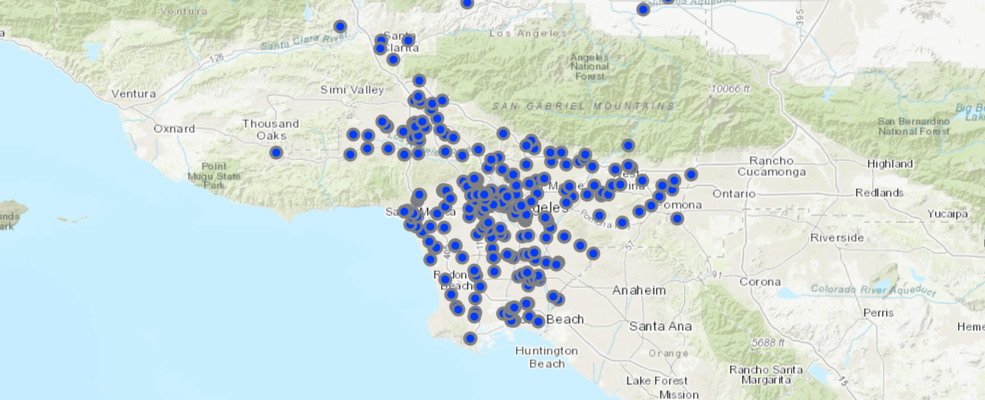

In [14]:
map1 = gis.map('Los Angeles, CA')
map1

In [16]:
sedf.spatial.plot(map1)
map1.take_screenshot(output_in_cell=False)

## Lines & Project Coordinate System

In [23]:
file_path = os.path.join(data_path, 'lines_pcs_wgs84_utm_z15n.shp')
geo_df = gpd.read_file(file_path)

In [24]:
print(geo_df.shape)
geo_df.head(2)

(197, 6)


,TextField,DateField,RepRowID,Enabled,SHAPE_Leng,geometry
0,GN,2009-03-17,1,1,59.403290,"LINESTRING (494930.125 4980335.462, 494948.221..."
1,GN,2009-03-17,2,1,77.864384,"LINESTRING (494948.221 4980334.866, 494971.954..."


In [25]:
geo_df.crs # prints EPSG for UTM, Zone 15 N

{'init': 'epsg:32615'}

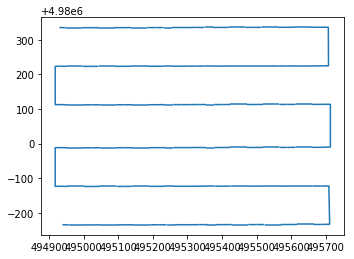

In [19]:
geo_df.plot()

In [21]:
%%time
sedf= pd.DataFrame.spatial.from_geodataframe(geo_df)
print(sedf.shape)
print(sedf.head(2))

(197, 7)
    DateField  Enabled  OBJECTID  RepRowID  \
0  2009-03-17        1         1         1   
1  2009-03-17        1         2         2   

                                               SHAPE  SHAPE_Leng TextField  
0  {'paths': [[[-93.06429968482732, 44.9764423659...   59.403290        GN  
1  {'paths': [[[-93.06407016865167, 44.9764371269...   77.864384        GN  
Wall time: 42.8 ms


MapView(layout=Layout(height='400px', width='100%'), zoom=13.0)


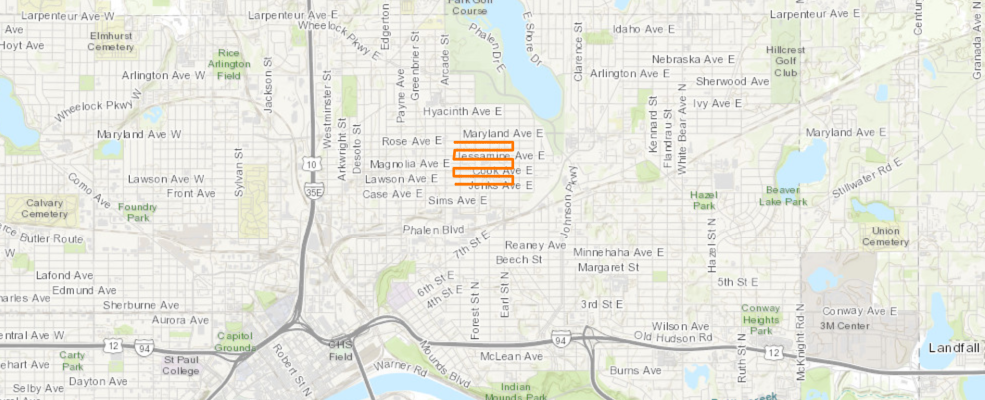

In [33]:
map2 = gis.map()
map2.center={'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'x': -10359153.165404981,
 'y': 5616711.30103032}
map2.zoom=13
map2

In [34]:
sedf.spatial.plot(map2)

True

In [35]:
map2.take_screenshot(output_in_cell=False)

## Polygons - Geographic coordinate system

In [36]:
%%time
file_path = os.path.join(data_path, 'polygons_gcs_wgs84.shp')
geo_df = gpd.read_file(file_path)
print(geo_df.shape)

(192, 6)
Wall time: 55 ms


In [37]:
geo_df.head(2)

,RepRowID,TextField,DateField,SHAPE_Leng,SHAPE_Area,geometry
0,1,GN,2009-03-17,397.743626,9378.271399,"POLYGON ((-93.06392 44.97687, -93.06392 44.976..."
1,2,GN,2009-03-17,397.743626,9378.271399,"POLYGON ((-93.06362 44.97687, -93.06362 44.976..."


In [39]:
%%time
sedf = pd.DataFrame.spatial.from_geodataframe(geo_df)
print(sedf.shape)

(192, 7)
Wall time: 47 ms


In [40]:
sedf.head(2)

,DateField,OBJECTID,RepRowID,SHAPE,SHAPE_Area,SHAPE_Leng,TextField
0,2009-03-17,1,1,"{'rings': [[[-93.06392094799334, 44.9768713364...",9378.271399,397.743626,GN
1,2009-03-17,2,2,"{'rings': [[[-93.06362116208389, 44.9768718658...",9378.271399,397.743626,GN


MapView(layout=Layout(height='400px', width='100%'), zoom=16.0)


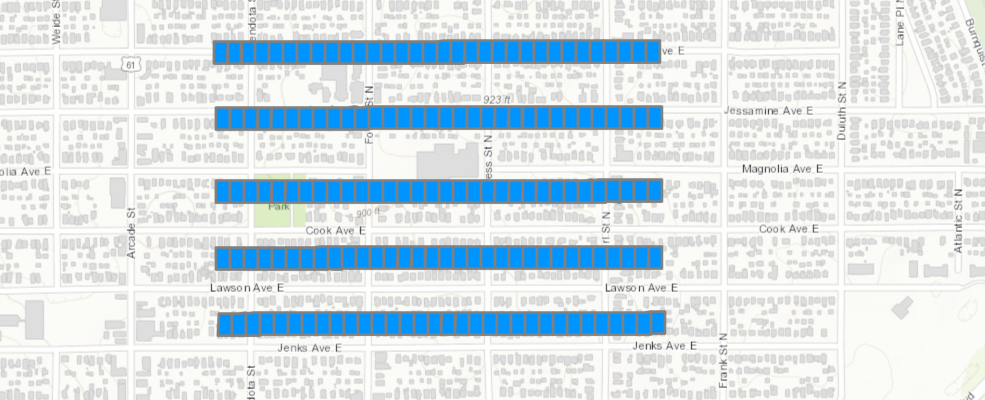

In [47]:
map3 = gis.map()
map3.center={'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'x': -10359193.77257626,
 'y': 5617344.295170828}
map3.zoom=16
map3

In [48]:
sedf.spatial.plot(map3)

True

In [49]:
map3.take_screenshot(output_in_cell=False)

## Very large data

In [ ]:
%%time

file1_path = os.path.join(large_data_path,'NYCTaxi_2','2015','yellow_tripdata_2015-01.csv')
file2_path = os.path.join(large_data_path,'NYCTaxi_2','2015','yellow_tripdata_2015-02.csv')
geo_df = gpd.read_file(file_path)
print(geo_df.shape)